In [2]:
import torch 
import torchvision 
from torchvision import transforms,datasets

In [3]:
train=datasets.MNIST('',train=True,download=True,transform=transforms.Compose([transforms.ToTensor()]))

In [4]:
test=datasets.MNIST('',train=False,download=True,transform=transforms.Compose([transforms.ToTensor()]))

In [5]:
trainset=torch.utils.data.DataLoader(train,batch_size=10,shuffle=True)
testset=torch.utils.data.DataLoader(test,batch_size=10,shuffle=False)

In [6]:
import torch.nn as nn 
import torch.nn.functional as F

### Its just like Object Oriented Programming 

✅ Building blocks to create and train neural networks easily

✅ Ready-made layers (like Linear, Conv2d), activation functions (like ReLU, Sigmoid), and loss functions (like CrossEntropyLoss)

✅ Tools to define models in a clean and modular way



In [7]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(28*28, 64)
        self.fc2=nn.Linear(64,64)
        self.fc3=nn.Linear(64,64)
        self.fc4=nn.Linear(64,10)

    def forward(self,x):
        x=F.relu(self.fx1(x))
        x=F.relu(self.fx2(x))
        x=F.relu(self.fx3(x))
        x=self.fx4(x)
        return F.log_softmax(x,dim=1)    
        
net=Net()
print(net)

Net(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=10, bias=True)
)


✅ You are defining a new neural network class called Net.

✅ It inherits from nn.Module — which is the base class in PyTorch for all neural network modules.

By inheriting from nn.Module, your class gets lots of built-in features, like .parameters(), .to(), .eval(), etc.

---------------------------------------------------------------------------------

### Program Part

You are creating a fully connected(dense) layer called fc1.

nn.Linear is a layer from torch.nn that applies 
            output=input * weights+bias

28*28 → The number of input features = 784

This is common when working with MNIST images, which are 28×28 pixels.

The image is flattened into a 1D vector of length 784 before passing into the layer.



64 → The number of output features

The layer will produce a vector of length 64.

### This layer learns to transform the raw pixel data (size 784) into a smaller, 64-dimensional representation that is hopefully more useful for the task (like classification).

In [9]:
X=torch.rand((28,28))
X =X.view(-1,28*28)


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return F.log_softmax(x, dim=1)

net = Net()
print(net)

X = torch.rand((28, 28))
X = X.view(-1, 28*28)
output = net(X)
print(output)


Net(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=10, bias=True)
)
tensor([[-2.2754, -2.2744, -2.4006, -2.4195, -2.3452, -2.2417, -2.2417, -2.3062,
         -2.1630, -2.3886]], grad_fn=<LogSoftmaxBackward0>)


# Using optimizers

In [17]:
import torch.optim as optim 

optimizer=optim.Adam(net.parameters(),lr=0.01)

EPOCHS =3 

for epoch in range(EPOCHS):
    for data in trainset:
        #data is a batch of featuresets and labels
        X,y=data
        net.zero_grad()
        output=net(X.view(-1,28*28))
        loss=F.nll_loss(output,y)
        loss.backward()
        optimizer.step()
    print(loss)
        
        

tensor(0.7231, grad_fn=<NllLossBackward0>)
tensor(0.0840, grad_fn=<NllLossBackward0>)
tensor(1.4679, grad_fn=<NllLossBackward0>)


### Now Accuracy

In [19]:
correct = 0
total = 0 

with torch.no_grad():
    for data in trainset:
        X,y=data
        output=net(X.view(-1,784))
        for idx,i in enumerate(output):
            if torch.argmax(i) == y[idx]:
                correct +=1
            total +=1
print("Accuracy:",round(correct/total,3))

Accuracy: 0.943


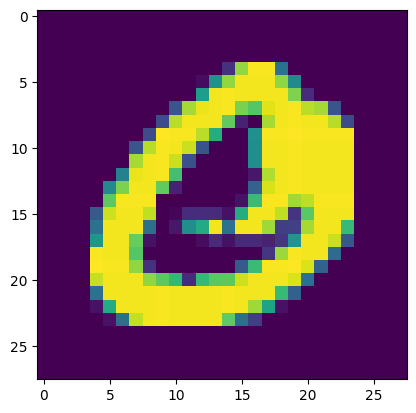

In [20]:
import matplotlib.pyplot as plt
plt.imshow(X[0].view(28,28))
plt.show()

In [23]:
print(torch.argmax(net(X[0].view(-1,784))))

tensor(0)


In [27]:
print(torch.argmax(net(X[1].view(-1,784))[0]))

tensor(4)
